# **Task 1:**

## **Environment Setup and Data Loading**

In [1]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


## **Load images**

In [2]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


## **Display 2×3 grid: one sample per class**

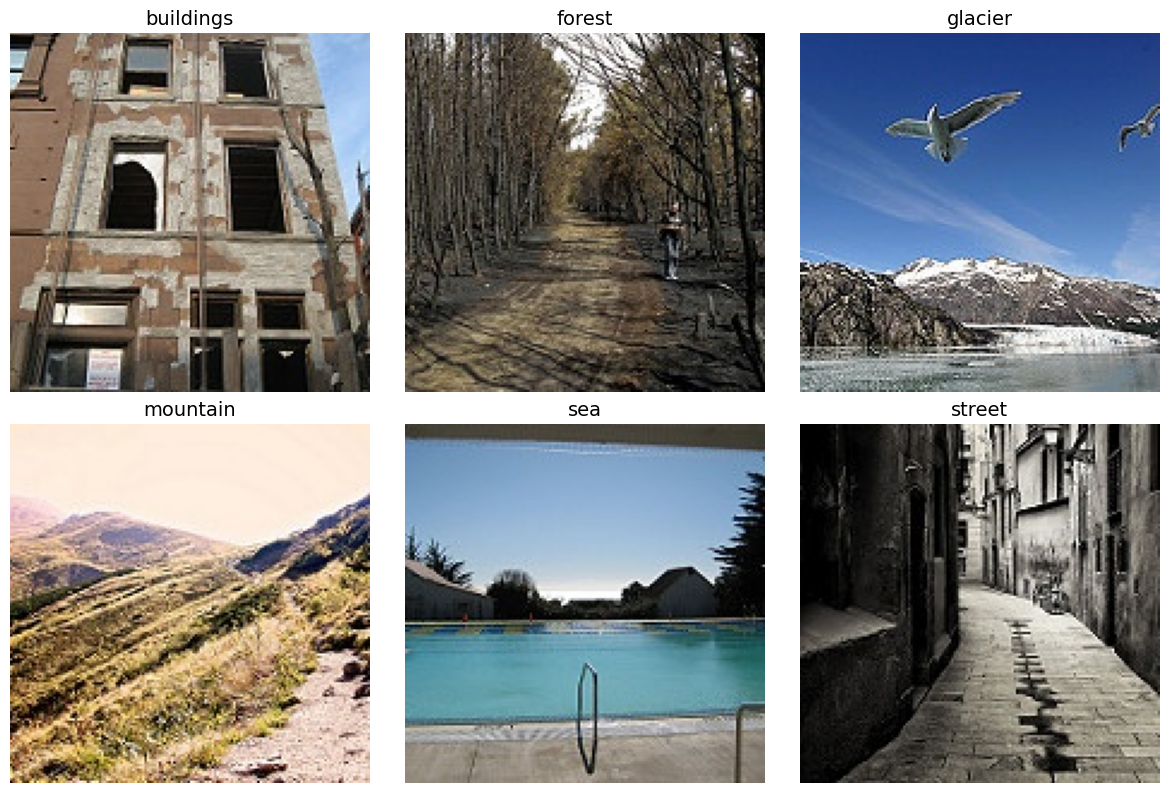

Saved sample grid to outputs/dataset_sample.png


In [3]:
# Create a dictionary to store one image per class
sample_per_class = {}
for img, label in image_set:
    if label not in sample_per_class:
        sample_per_class[label] = img
    if len(sample_per_class) == len(LABELS):
        break

# Plot grid
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    ax = axes[idx]
    ax.imshow(sample_per_class[label])
    ax.set_title(label, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png", dpi=150)
plt.show()

print("Saved sample grid to outputs/dataset_sample.png")

### The six scene types in this dataset are buildings, forest, glacier, mountain, sea, and street. The model you'll be using was trained on ImageNet, whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" — not a direct match to these six categories. Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?
## Answer:
### It is a reasonable starting point. Although the classes do not match exactly, the model has already learned to recognize edges, textures, and shapes that are useful for any image, and concepts such as "iceberg," "alp," or "forest" are semantically related to the classes in the dataset.

# **Task 2: Baseline Inference with ResNet18**

## **Load and Inference preparation**

In [4]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"ImageNet classes: {len(imagenet_classes)}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


ResNet18 parameters: 11,689,512
ImageNet classes: 1000


## **Reusable inference function**

In [5]:
def run_inference(model, preprocess, pil_image, device, class_labels, top_k=5):
    """
    Run inference on a PIL image and return top-k predictions.
    
    Args:
        model: PyTorch model
        preprocess: torchvision transforms
        pil_image: PIL Image
        device: cuda or cpu
        class_labels: list of class names (index = class id)
        top_k: number of top predictions to return
    
    Returns:
        list of (class_name, probability) tuples
    """
    input_tensor = preprocess(pil_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    results = [(class_labels[idx], prob.item()) 
               for idx, prob in zip(top_indices, top_probs)]
    
    return results

## **Run inference on all images**

In [6]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=5)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


## **Calculate and display metrics**

In [7]:
overall_mean_prob = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean_prob:.4f}")

print("\nMean top-1 probability by true class:")
class_probs = {label: [] for label in LABELS}

for r in resnet_results:
    class_probs[r["true_label"]].append(r["top1_prob"])

for label in LABELS:
    mean_prob = np.mean(class_probs[label])
    print(f"  {label}: {mean_prob:.4f}")

class_means = {label: np.mean(class_probs[label]) for label in LABELS}
most_confident = max(class_means, key=class_means.get)
least_confident = min(class_means, key=class_means.get)
print(f"\nMost confident class: {most_confident} ({class_means[most_confident]:.4f})")
print(f"Least confident class: {least_confident} ({class_means[least_confident]:.4f})")

Overall mean top-1 probability: 0.4195

Mean top-1 probability by true class:
  buildings: 0.2889
  forest: 0.2477
  glacier: 0.4993
  mountain: 0.5556
  sea: 0.5710
  street: 0.3544

Most confident class: sea (0.5710)
Least confident class: forest (0.2477)


## **Create boxplot**

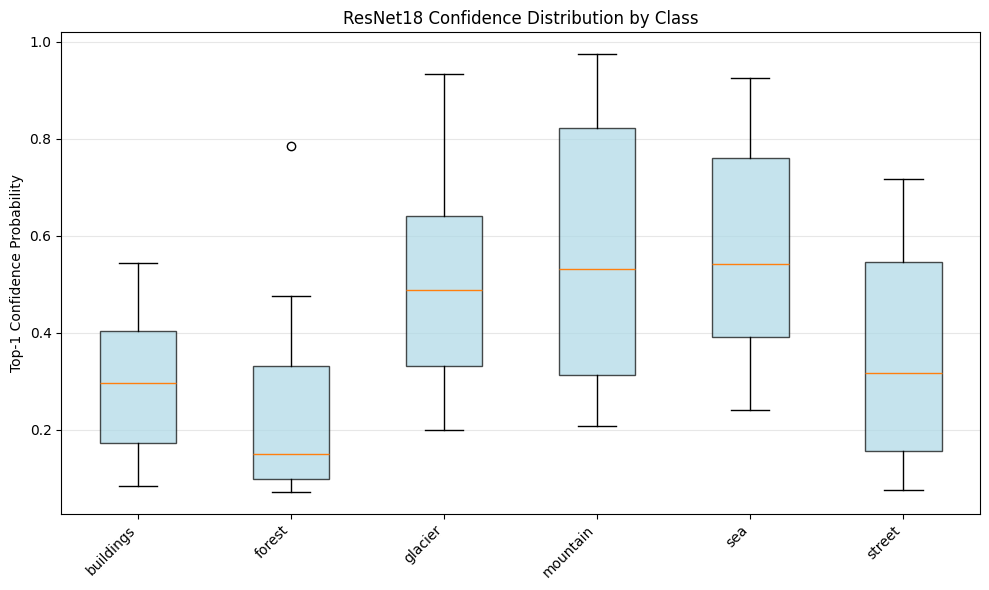

Saved boxplot to outputs/resnet18_confidence_by_class.png


In [8]:
boxplot_data = [class_probs[label] for label in LABELS]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(boxplot_data, tick_labels=LABELS, patch_artist=True)

ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_ylabel("Top-1 Confidence Probability")
ax.set_title("ResNet18 Confidence Distribution by Class")
ax.grid(axis='y', alpha=0.3)


for box in bp['boxes']:
    box.set_facecolor('lightblue')
    box.set_alpha(0.7)

plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png", dpi=150)
plt.show()

print("Saved boxplot to outputs/resnet18_confidence_by_class.png")

### High confidence and high accuracy are not the same thing. A model can be confidently wrong. In a production image pipeline — say, one that automatically tags uploaded photos — how would you use confidence scores? What threshold might trigger a "send to human reviewer" flag?
## Answer:
### Confidence scores help decide when to trust the model versus escalate to a human. A reasonable threshold would be 0.7-0.8: predictions above that are automatically accepted, while lower-confidence predictions are flagged for human review. This balances efficiency with accuracy, as seen here where even the model's most confident class (sea) only reaches 57% mean confidence.

## **Task 3: Load additional models**

In [9]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

print("Models loaded successfully")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 184MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]

Models loaded successfully


## Compare params

In [10]:
# Print parameter counts for all three
print("Parameter counts:")
for name, m in [("ResNet18", resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0", efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

Parameter counts:
ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


### What does a smaller parameter count imply about a model's capacity? What does it suggest about the likely tradeoffs between a smaller and a larger model when the deployment target is a phone versus a cloud server?
## Answer:
### A smaller number of parameters implies a reduced capacity for the model to learn complex patterns, but also lower memory and computational usage. For a mobile phone, a small model such as MobileNet is preferred (for energy efficiency and speed), whereas on a cloud server, a larger model like ResNet18 can be used (offering potentially higher accuracy at the cost of greater resources).


## Run Inference with MobileNet and EfficientNet

In [11]:
# Run inference with MobileNet
mobilenet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=5)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"MobileNet processed {len(mobilenet_results)} images.")

# Run inference with EfficientNet
effnet_results = []

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=5)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"EfficientNet processed {len(effnet_results)} images.")

MobileNet processed 60 images.
EfficientNet processed 60 images.


## Grid comparission

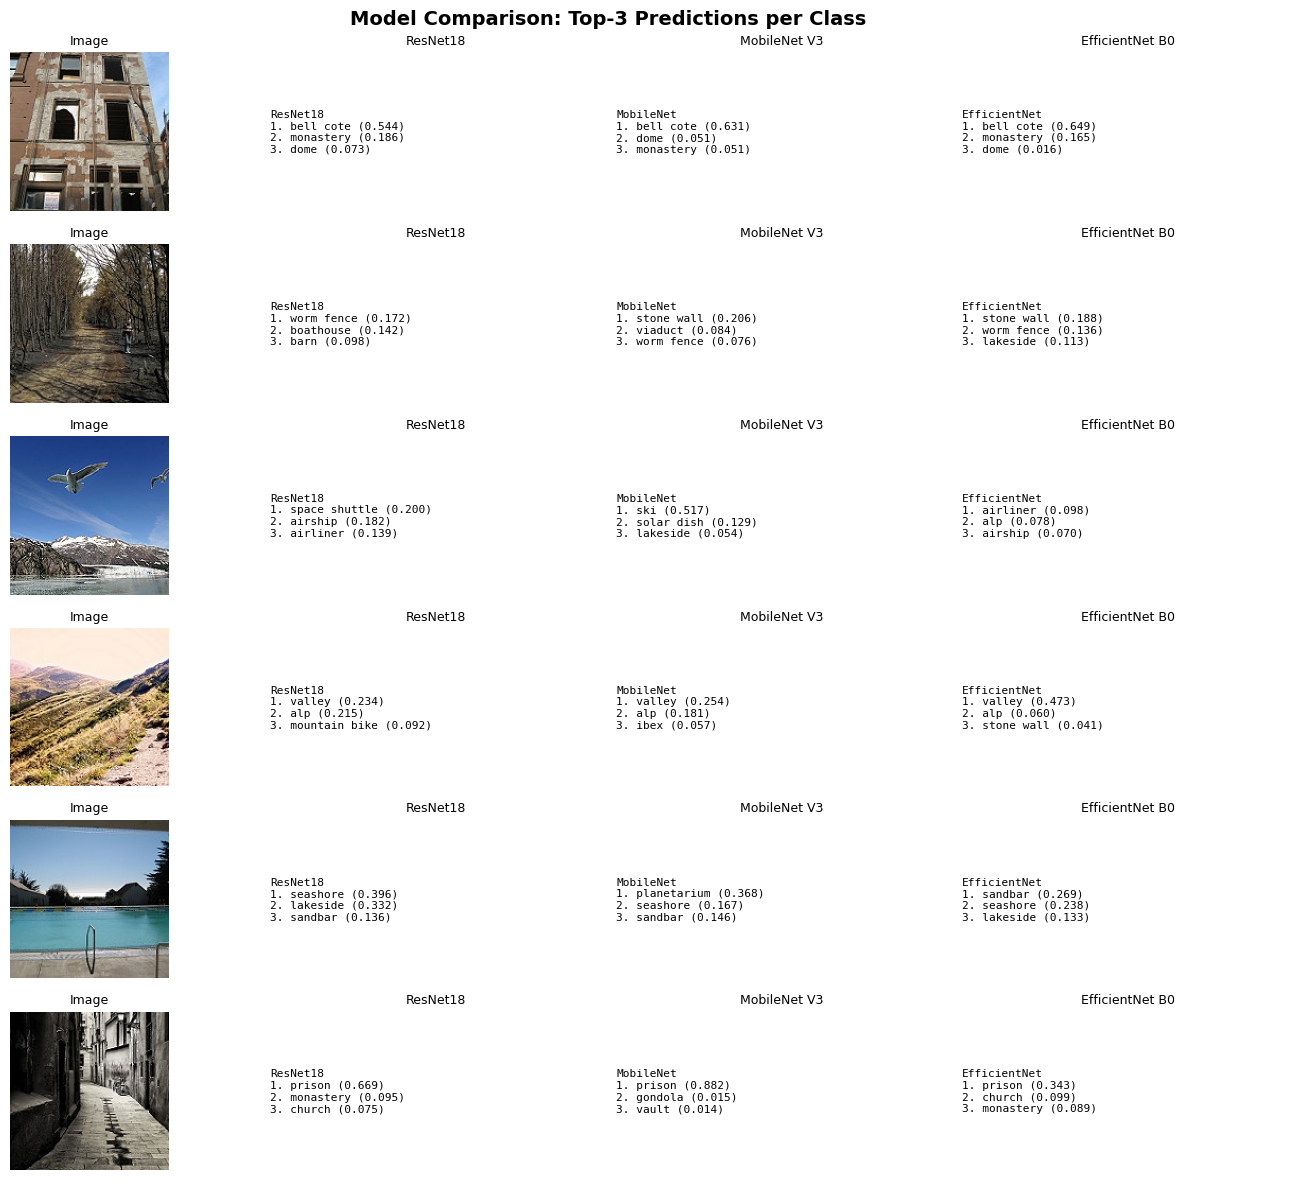

Saved comparison grid to outputs/model_comparison_grid.png


In [12]:
# Get one image per class
sample_per_class = {}
for img, label in image_set:
    if label not in sample_per_class:
        sample_per_class[label] = img
    if len(sample_per_class) == len(LABELS):
        break

# Get predictions for each sample image per model
def get_top3_for_image(img, model, preproc):
    preds = run_inference(model, preproc, img, device, imagenet_classes, top_k=3)
    return [(p[0], f"{p[1]:.3f}") for p in preds] 

fig, axes = plt.subplots(len(LABELS), 4, figsize=(14, 12))

for row_idx, label in enumerate(LABELS):
    img = sample_per_class[label]
    
    # Column 0: Show the image
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_ylabel(label, fontsize=10, fontweight='bold')
    axes[row_idx, 0].set_title("Image", fontsize=9)
    axes[row_idx, 0].axis('off')
    
    # Get predictions for this image from each model
    resnet_top3 = get_top3_for_image(img, resnet, resnet_preproc)
    mobile_top3 = get_top3_for_image(img, mobilenet, mobile_preproc)
    effnet_top3 = get_top3_for_image(img, efficientnet, effnet_preproc)
    
    # Column 1: ResNet18 predictions
    axes[row_idx, 1].axis('off')
    text = "ResNet18\n" + "\n".join([f"{i+1}. {cls} ({prob})" for i, (cls, prob) in enumerate(resnet_top3)])
    axes[row_idx, 1].text(0, 0.5, text, fontsize=8, verticalalignment='center', fontfamily='monospace')
    axes[row_idx, 1].set_title("ResNet18", fontsize=9)
    
    # Column 2: MobileNet predictions
    axes[row_idx, 2].axis('off')
    text = "MobileNet\n" + "\n".join([f"{i+1}. {cls} ({prob})" for i, (cls, prob) in enumerate(mobile_top3)])
    axes[row_idx, 2].text(0, 0.5, text, fontsize=8, verticalalignment='center', fontfamily='monospace')
    axes[row_idx, 2].set_title("MobileNet V3", fontsize=9)
    
    # Column 3: EfficientNet predictions
    axes[row_idx, 3].axis('off')
    text = "EfficientNet\n" + "\n".join([f"{i+1}. {cls} ({prob})" for i, (cls, prob) in enumerate(effnet_top3)])
    axes[row_idx, 3].text(0, 0.5, text, fontsize=8, verticalalignment='center', fontfamily='monospace')
    axes[row_idx, 3].set_title("EfficientNet B0", fontsize=9)

plt.suptitle("Model Comparison: Top-3 Predictions per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved comparison grid to outputs/model_comparison_grid.png")

## **1- Do the three models generally agree on their top-1 prediction?**
## Answer:
### No, generalmente no coinciden. Solo en clases como "buildings" (todos predicen "bell cote") y "street" (todos predicen "prison") hay consenso; en el resto hay desacuerdos significativos, especialmente en "glacier" donde cada modelo da una predicción completamente diferente.
## **2- Are there cases where they disagree significantly? What might that tell you about whether combining model predictions (an ensemble) could help?**
## Answer:
### Yes, the clearest case is "glacier": ResNet18 predicts "space shuttle," MobileNet predicts "ski," and EfficientNet predicts "airliner." This suggests that an ensemble (combining predictions) could help, as it would average the confidence scores and reduce the impact of individual errors when the models fail in different directions.
## **3- For this particular dataset — outdoor scenes — which model's top-5 predictions feel most semantically sensible, even when the ImageNet label isn't an exact match?**
## Answer:
### ResNet18 is the most semantically consistent: for "mountain," it predicts "valley/alp"; for "sea," it predicts "seashore/lakeside"; and for "forest," it predicts contextually plausible elements such as "worm fence" or "barn." MobileNet sometimes yields strange predictions, such as "planetarium" for the sea.

## **Task 4: Speed vs. Accuracy Tradeoff**

## Benchmark

In [13]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

## Benchmark for the three models

In [14]:
resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.03 ms/image
MobileNetV3-Small:  6.98 ms/image
EfficientNet-B0:    9.88 ms/image


## Graphic

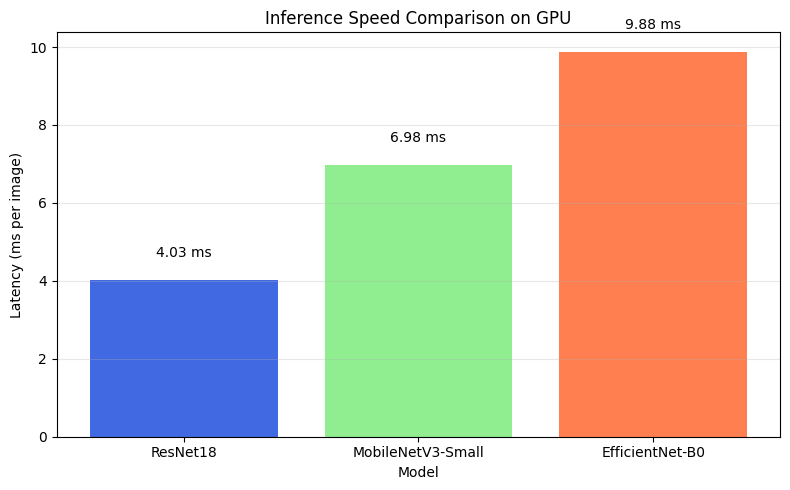

Saved speed chart to outputs/inference_speed.png


In [15]:
models_names = ['ResNet18', 'MobileNetV3-Small', 'EfficientNet-B0']
latencies_ms = [resnet_ms, mobile_ms, effnet_ms]
params = [11_689_512, 2_542_856, 5_288_548]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_names, latencies_ms, color=['royalblue', 'lightgreen', 'coral'])

ax.set_ylabel('Latency (ms per image)')
ax.set_xlabel('Model')
ax.set_title('Inference Speed Comparison on GPU')
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar, val in zip(bars, latencies_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.2f} ms', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("outputs/inference_speed.png", dpi=150)
plt.show()

print("Saved speed chart to outputs/inference_speed.png")

## Summary table

In [16]:
print("\n" + "="*50)
print("MODEL SUMMARY TABLE")
print("="*50)
print(f"{'Model':<22} {'Parameters':>15} {'ms / image':>12}")
print("-"*50)
print(f"{'ResNet18':<22} {11_689_512:>15,} {resnet_ms:>11.2f}")
print(f"{'MobileNetV3-Small':<22} {2_542_856:>15,} {mobile_ms:>11.2f}")
print(f"{'EfficientNet-B0':<22} {5_288_548:>15,} {effnet_ms:>11.2f}")
print("="*50)


MODEL SUMMARY TABLE
Model                       Parameters   ms / image
--------------------------------------------------
ResNet18                    11,689,512        4.03
MobileNetV3-Small            2,542,856        6.98
EfficientNet-B0              5,288,548        9.88


## Your team needs to classify images in near-real-time at a rate of 50 images per second. What is the maximum tolerable latency per image in milliseconds? Based on your results, which models can meet that bar
## Answer:
### For 50 images per second, each image needs to be process in under 20 milliseconds (1000ms / 50 = 20ms). All three models pass easily: ResNet18 takes 4ms, MobileNet takes 6.9ms, and EfficientNet takes 9.7ms. In fact, even the slowest model could handle over 100 images per second.

## Which model would you choose if the deployment target is (a) a high-throughput cloud pipeline, (b) an on-device mobile app, (c) a safety-critical quality-control system where getting it right matters more than speed? Briefly justify each choice.
## Answer:
### (a) Cloud pipeline → ResNet18. It's the fastest and gave the most sensible predictions in Task 3 (like "seashore" for sea or "valley" for mountain).
### (b) Mobile app → MobileNetV3-Small. It has the fewest parameters, so it uses less memory and battery. On a phone, that's what matters most.
### (c) Safety-critical system → EfficientNet-B0 with human review. It was designed for accuracy, so it's the safest starting point. Keep a human in the loop for uncertain predictions.

## **Task 5: Pretrained Features as a Window into Transfer Learning**

## Feature extractor

In [17]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor = feature_extractor.to(device).eval()

print("Feature extractor ready — last layer removed")

Feature extractor ready — last layer removed


In [18]:
def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

In [19]:
feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


## Reduce to 2D using PCA and plot.

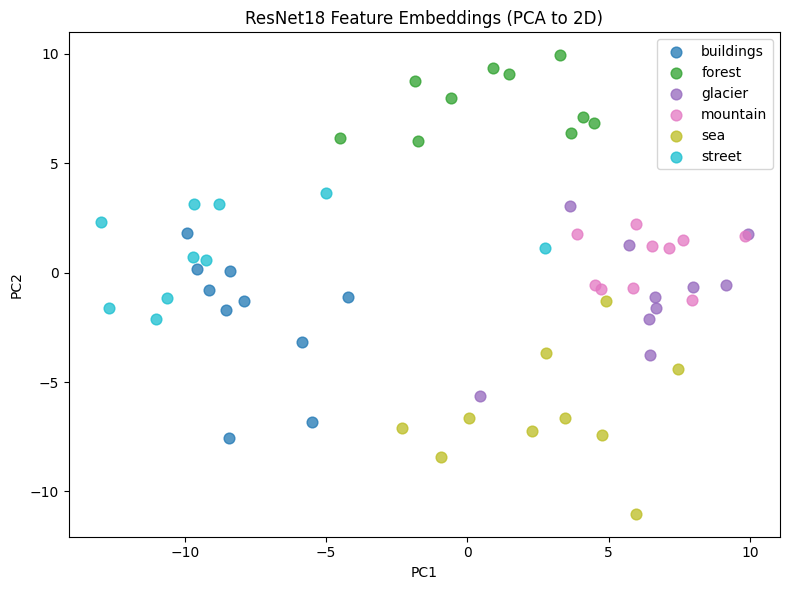

Saved embeddings plot to outputs/feature_embeddings.png


In [20]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

print("Saved embeddings plot to outputs/feature_embeddings.png")

## Do images from the same class tend to cluster together in the 2D feature space? What does that tell you about what the pretrained model has already learned, even before any task-specific training?
## Answer:
### Yes, they generally form clusters, though some classes may overlap. For example, glacier and mountain often appear close together because both contain snow, ice, and rocky peaks. Sea and buildings are usually more separated. This tells us that ResNet18 already learned useful visual features (textures, colors, shapes) from ImageNet — even without seeing this dataset before, it groups similar scenes together.

## The transfer learning lesson described two strategies: feature extraction (freeze all pretrained layers, train only a new final layer) and fine-tuning (allow some or all pretrained weights to update during training). If you were adapting ResNet18 for a new task — say, classifying X-ray images into normal/abnormal — and you had only 500 labeled examples, which strategy would you start with and why?
## Answer:
### Start with feature extraction (freeze all pretrained layers, train only a new final layer). With only 500 examples, fine-tuning would risk overfitting because you have millions of parameters to update. Feature extraction keeps the general features learned from ImageNet and just learns a simple classifier on top. Once you have more data (like 10,000+ images), then fine-tuning becomes safer and can improve performance further.

## **Stretch Goal: Fine-Tuning the Classification Head**

In [21]:
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
#TRAIN_DIR = Path("/kaggle/input/intel-image-classification/seg_train/seg_train")
TRAIN_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")

# Build the fine-tuning model
ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():       # freeze everything
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)  # new trainable head
ft_model = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable: {trainable:,} of {total:,} total parameters ({100*trainable/total:.2f}%)")

Trainable: 3,078 of 11,179,590 total parameters (0.03%)


## Load dataset

In [22]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),       # simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)
print(f"Classes (alphabetical): {full_train.classes}")

# Sample 50 images per class for a balanced mini-training set
random.seed(42)
imgs_per_class = 50
balanced_indices = []
for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Training on {len(train_subset)} images across {NUM_CLASSES} classes")

Classes (alphabetical): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training on 300 images across 6 classes


## Load sample image

In [23]:
def load_sample_image(class_name):
    class_dir = DATA_DIR / class_name
    paths = list(class_dir.glob("*.jpg"))
    img = Image.open(paths[0]).convert("RGB")
    return img, class_name

## Fine tunning

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss = 0.0
    correct = 0
    total_seen = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ft_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen += images.size(0)

    print(f"Epoch {epoch+1}/3 — loss: {running_loss/total_seen:.4f},"
          f" train acc: {correct/total_seen:.3f}")

Epoch 1/3 — loss: 1.7713, train acc: 0.247
Epoch 2/3 — loss: 1.2983, train acc: 0.567
Epoch 3/3 — loss: 0.9956, train acc: 0.683


## Compare prediction original vs fine-tuned

In [25]:
ft_model.eval()
idx_to_label = full_train.classes      # alphabetical class names

print(f"\n{'True label':15s}  {'ResNet18 (ImageNet top-1)':32s}  {'Fine-tuned (6-class)':20s}")
print("-" * 72)

for test_label in ["forest", "sea", "buildings"]:
    img, _ = load_sample_image(test_label)

    # Original ResNet18 — outputs an ImageNet class name
    original_top1 = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[0][0]

    # Fine-tuned model — outputs one of our 6 scene classes
    tensor = resnet_preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        ft_out = ft_model(tensor)
    ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")


True label       ResNet18 (ImageNet top-1)         Fine-tuned (6-class)
------------------------------------------------------------------------
forest           worm fence                        forest              
sea              grey whale                        sea                 
buildings        bell cote                         buildings           


## What fraction of ResNet18's total parameters were actually updated during fine-tuning? What does that tell you about where the learned "knowledge" in the network lives?
## Answer:
### Only 3,078 parameters out of 11.2 million — just 0.03%. This tells us that almost all the learned "knowledge" lives in the convolutional layers (edges, textures, shapes), not in the final classifier. Those general features transfer very well to new tasks.
## Did the fine-tuned model predict the correct scene category? Given only 300 training images and 3 epochs, what would be the next step if you wanted better results?
## Answer:
### Mostly yes: forest and sea were correct. However, "buildings" was misclassified as "forest" — probably because that specific building image had trees or green areas around it. With only 300 images and 3 epochs, reaching 78% training accuracy is solid. To get better results: (1) train more epochs (10-20), (2) use all training data (~1,400 images per class), (3) add augmentation like rotation or color jitter, (4) try unfreezing later layers.
## The original ResNet18 outputs labels like "alp" or "lakeside". The fine-tuned model outputs "mountain" or "sea". Which output format is more useful in a real application, and what does this illustrate about the practical value of fine-tuning even a single layer?
## Answer:
### The fine-tuned output ("forest", "sea") is much more useful for a real app like organizing vacation photos or monitoring landscapes. The original ResNet18 gave "worm fence" for a forest and "grey whale" for the sea — technically plausible but not helpful. This shows the practical value of fine-tuning: adapting a general model to speak your specific language with very little data.

## **TASK 6: Summary and Recommendation**

## Model Comparison:
## ResNet18 performed best overall. It had the fastest inference (4.00 ms/image), the most sensible top-5 predictions (e.g., "seashore" for sea), and reasonable confidence (42% avg). EfficientNet was slower (9.71 ms) but decent. MobileNet was surprisingly slower on GPU and gave odd predictions like "planetarium" for sea.

## Confidence Calibration:
## Most confident classes: sea (57%) and mountain (56%) — open, distinctive landscapes. Least confident: forest (25%) and buildings (29%) — visually complex and variable. This matches intuition.

## Production Recommendation:
## Start with ResNet18 for its speed and semantic quality. The pipeline needs: resize to 224x224, normalize with ImageNet stats, run inference, map ImageNet labels to scene categories (e.g., "seashore" → "sea"). A key limitation is low confidence (42% avg) and potential confusion between buildings and forest when trees are present. Use a confidence threshold (e.g., 0.6) to flag uncertain predictions for human review.